In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
# Loading the raw dataset
df_raw = pd.read_csv("../data/raw/imports-85.data")


#Printing out the columns, count of the non-null values, and the data type
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   3            204 non-null    int64  
 1   ?            204 non-null    str    
 2   alfa-romero  204 non-null    str    
 3   gas          204 non-null    str    
 4   std          204 non-null    str    
 5   two          204 non-null    str    
 6   convertible  204 non-null    str    
 7   rwd          204 non-null    str    
 8   front        204 non-null    str    
 9   88.60        204 non-null    float64
 10  168.80       204 non-null    float64
 11  64.10        204 non-null    float64
 12  48.80        204 non-null    float64
 13  2548         204 non-null    int64  
 14  dohc         204 non-null    str    
 15  four         204 non-null    str    
 16  130          204 non-null    int64  
 17  mpfi         204 non-null    str    
 18  3.47         204 non-null    str    
 19  2.68         204 no

In [ ]:
# Printing the first 10 columns of the dataframe
df_raw.head(10)


,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
5,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
6,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
7,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
8,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?
9,2,192,bmw,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16430


In [12]:
# Load raw dataset with correct headers
headers = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location", "wheel-base",
    "length", "width", "height", "curb-weight", "engine-type", "num-of-cylinders",
    "engine-size", "fuel-system", "bore", "stroke", "compression-ratio",
    "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
df = pd.read_csv(url, names=headers, na_values="?")



In [13]:
# 1. Inspect missing values
print("--- Missing Values Count ---")
print(df.isna().sum()[df.isna().sum() > 0])


--- Missing Values Count ---
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64


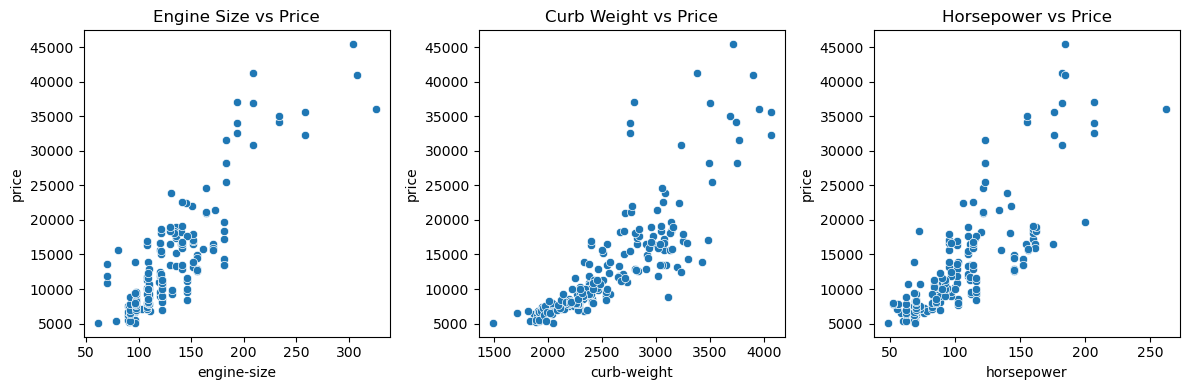

In [14]:
# Physical & Mechanical Drivers of Price
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='engine-size', y='price')
plt.title('Engine Size vs Price')

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='curb-weight', y='price')
plt.title('Curb Weight vs Price')

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='horsepower', y='price')
plt.title('Horsepower vs Price')

plt.tight_layout()
plt.show()

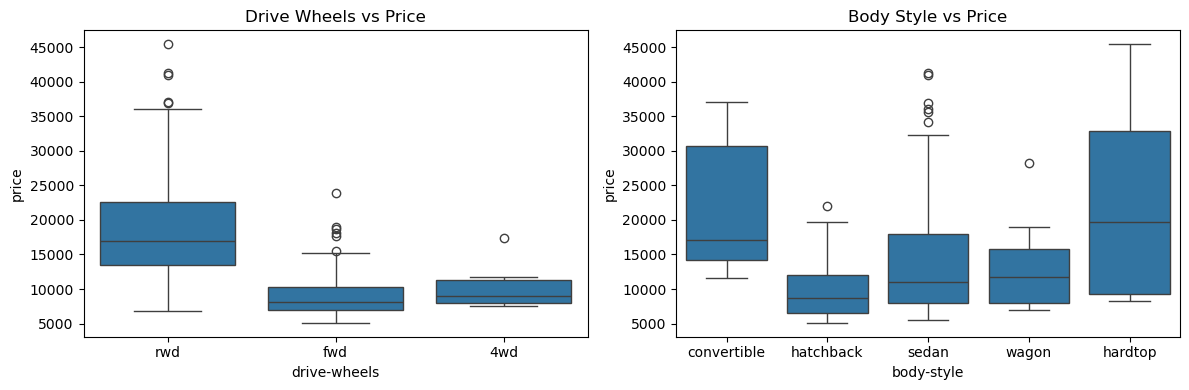

In [15]:
#  Categorical Price Drivers
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='drive-wheels', y='price')
plt.title('Drive Wheels vs Price')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='body-style', y='price')
plt.title('Body Style vs Price')

plt.tight_layout()
plt.show()